# 随机实验分析教程

### 现金激励能让人去领取 HIV 检测结果吗

2004 年，马拉维农村的一项研究为几千名居民免费做了 HIV 检测。检测结果要过几周到附近的临时站点去领。很多人做了检测却不去领结果。Thornton (2008) 做了一个实验，随机发给每个人一张面额不等的代金券，凭券领取结果时可以兑换现金，有些人抽到的面额是 0。

随机实验是因果推断的基准。其他所有方法，匹配、工具变量、断点、DID，都是在没有实验的时候设法逼近它。分析一个实验看起来只需要比较两组均值，但把它做对、做完整，仍然有一套讲究。数据随 StatsPAI 自带，本教程全程离线。

| 节 | 内容 | 你会学到 |
| --- | --- | --- |
| 1 | 随机化为什么有用 | 它消除的是什么 |
| 2 | 数据与实验设计 | 结果、处理、样本 |
| 3 | 平衡性检查 | 它检查的是随机化的执行，不是因果假设 |
| 4 | 均值差 | 最简单也最可信的估计量，Neyman 标准误 |
| 5 | 随机化推断 | 不依赖大样本近似的精确检验，亲手做一遍置换 |
| 6 | 协变量调整 | 为了精度而不是为了无偏，Lin 估计量 |
| 7 | 剂量反应 | 激励金额越大效果越大吗 |
| 8 | 异质性与多重检验 | 分组分析为什么需要校正 |
| 9 | 功效分析 | 做实验之前该算什么 |
| 10 | 小结 | 一份清单 |

## 1. 随机化为什么有用

每个人有两个潜在结果，$Y_i(1)$ 是拿到激励时会不会去领结果，$Y_i(0)$ 是没有激励时会不会去。个体的因果效应是 $Y_i(1) - Y_i(0)$，但我们永远只能看到其中一个。

比较拿到激励和没拿到激励的两组人，得到的是

$$
\underbrace{E[Y \mid D = 1] - E[Y \mid D = 0]}_{\text{观测到的均值差}}
= \underbrace{E[Y(1) - Y(0) \mid D = 1]}_{\text{处理组的平均效应}}
+ \underbrace{E[Y(0) \mid D = 1] - E[Y(0) \mid D = 0]}_{\text{选择偏差}} .
$$

如果激励是人们自己选的，或者是研究者按某种标准发的，两组人在没有激励时的行为本来就可能不同，第二项不为 0。

随机分配使处理 $D$ 与潜在结果独立。

$$
\big(Y(0),\, Y(1)\big) \;\perp\; D .
$$

于是选择偏差那一项**恰好为 0**，处理组的平均效应也等于总体的平均效应。均值差就是平均处理效应的无偏估计。这个结论不需要任何模型，不需要控制任何变量，也不需要假设没有遗漏变量。可观测和不可观测的特征在两组之间的分布都相同。

In [1]:
import warnings

warnings.filterwarnings("ignore")  # 教程里隐藏无关提示，正式分析时建议保留

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statspai as sp

plt.rcParams["figure.dpi"] = 80
pd.set_option("display.width", 120)
print("StatsPAI 版本:", sp.__version__)

StatsPAI 版本: 1.39.2


## 2. 数据与实验设计

`sp.datasets.thornton_hiv(complete_case=True)` 返回结果变量和处理变量都有记录的 2,834 人。

| 变量 | 含义 | 角色 |
| --- | --- | --- |
| `got` | 是否领取了 HIV 检测结果 | **结果变量** |
| `any` | 是否抽到了面额大于 0 的代金券 | **处理变量** |
| `tinc` | 代金券金额（美元） | 第 7 节的处理强度 |
| `distvct` | 住处到结果领取站点的距离（公里） | 协变量 |
| `age`, `male` | 年龄，性别 | 协变量 |
| `hiv2004` | 检测结果 | 协变量 |
| `villnum` | 村庄编号 | |

In [2]:
df = sp.datasets.thornton_hiv(complete_case=True)

print(df.shape)
print("\n处理分配:")
print(df["any"].value_counts().rename({1.0: "有激励", 0.0: "无激励"}).to_string())
print(f"\n激励金额: 平均 {df.loc[df['any'] == 1, 'tinc'].mean():.2f} 美元，最高 {df['tinc'].max():.2f} 美元")

(2834, 17)

处理分配:
any
有激励    2211
无激励     623

激励金额: 平均 1.29 美元，最高 2.84 美元


大约 78% 的人抽到了正面额，22% 的人抽到 0。两组人数不等不影响估计的无偏性，只影响精度。给定总样本量，两组各占一半时精度最高。

金额都不大，最高不到 3 美元。

## 3. 平衡性检查

随机化保证两组在**期望上**相同。具体到一次实验，两组的协变量均值会有随机的小差别。平衡表用来检查随机化有没有被正确执行，比如有没有人事后换了组，数据有没有录错。

它**不是**对因果识别假设的检验。实验的识别来自随机化这个事实本身，不取决于平衡表好不好看。

In [3]:
covs = ["age", "male", "distvct", "hiv2004"]
print(sp.balance_table(df.dropna(subset=covs), treat="any", covariates=covs))

Balance Table
         Treated Mean Treated SD Control Mean Control SD     Diff     SMD p-value
Variable                                                                         
age              33.7       13.8         32.1       12.9     1.61   0.120   0.007
male            0.462      0.499        0.470      0.500  -0.0083  -0.017   0.716
distvct          2.03       1.28         1.96       1.23    0.070   0.055   0.217
hiv2004         0.058      0.252        0.058      0.254    0.000   0.000   1.000
N                2208                     621                                    


性别、距离和 HIV 检测结果在两组之间几乎没有差别。年龄相差 1.6 岁，p 值是 0.006。

这需要担心吗？两点考虑。

- 检查的变量多了，偶尔出现一个显著的差别是正常的。按 5% 的水平检验 20 个变量，平均就会有 1 个「显著」。
- 更该看的是差别的大小。年龄的标准化均值差是 0.12，属于轻微的不平衡。

稳妥的做法是在第 6 节把年龄作为协变量放进回归，看结论是否变化。实验分析里协变量调整不是必需的，但它是对这类偶然不平衡的一道保险。

## 4. 均值差

In [4]:
mean_t = df.loc[df["any"] == 1, "got"].mean()
mean_c = df.loc[df["any"] == 0, "got"].mean()

print(f"有激励组领取结果的比例 : {mean_t:.3f}")
print(f"无激励组领取结果的比例 : {mean_c:.3f}")
print(f"均值差                 : {mean_t - mean_c:.3f}")

有激励组领取结果的比例 : 0.789
无激励组领取结果的比例 : 0.339
均值差                 : 0.451


没有激励时只有 34% 的人去领结果，有激励时是 79%。差距 45 个百分点。

均值差的标准误由 Neyman 给出。

$$
\widehat{SE} = \sqrt{\frac{s_1^2}{n_1} + \frac{s_0^2}{n_0}},
$$

其中 $s_1^2$ 和 $s_0^2$ 是两组各自的样本方差。它允许两组方差不同，对应方差不等的两样本 t 检验。

把结果变量对处理虚拟变量做回归，系数就是均值差，HC2 稳健标准误恰好等于 Neyman 标准误。所以「跑回归」和「比均值」在这里是同一件事。

In [5]:
n1, n0 = (df["any"] == 1).sum(), (df["any"] == 0).sum()
s1, s0 = df.loc[df["any"] == 1, "got"].var(), df.loc[df["any"] == 0, "got"].var()
neyman_se = np.sqrt(s1 / n1 + s0 / n0)

tt = sp.ttest(df, y="got", by="any", unequal=True)
reg = sp.regress("got ~ any", data=df, robust="hc2")

print(f"手工计算的 Neyman 标准误     : {neyman_se:.6f}")
print(f"回归 + HC2 稳健标准误        : {reg.std_errors['any']:.6f}")
print(f"回归系数                     : {reg.params['any']:.4f}")
print(f"95% 置信区间                 : [{reg.conf_int_lower['any']:.3f}, {reg.conf_int_upper['any']:.3f}]")
print()
print(tt)

手工计算的 Neyman 标准误     : 0.020865
回归 + HC2 稳健标准误        : 0.020865
回归系数                     : 0.4506
95% 置信区间                 : [0.410, 0.491]

TTestResult(Two-sample t test with unequal variances (Satterthwaite's degrees of freedom): estimate=-0.450552, t=-21.5934, df=898.159, p=1.274e-83)


两种算法的标准误一致到小数点后六位。效应的 95% 置信区间是 41 到 49 个百分点。

实验是按个人随机的，所以标准误不需要聚类。如果实验是按村庄随机（同一个村的人要么都有激励，要么都没有），就必须按村庄聚类。**聚类的层级由随机化的层级决定**。

## 5. 随机化推断

上面的 t 检验依赖中心极限定理。Fisher 提出了一种不需要任何近似的检验，它的全部随机性只来自随机分配本身。

**精确原假设**（sharp null）是激励对**每一个人**都没有效应，$Y_i(1) = Y_i(0)$ 对所有 $i$ 成立。在这个假设下，每个人的结果与他抽到什么券无关，我们观测到的结果就是他在任何分配下都会有的结果。

于是可以问，假如把「有激励」的标签在这 2,834 人里重新随机发一遍，均值差会是多少？重复很多次，就得到了原假设下均值差的**精确分布**。p 值是这个分布里比实际观测值更极端的比例。

先手工做一遍。

In [6]:
rng = np.random.default_rng(0)
y = df["got"].to_numpy()
d = df["any"].to_numpy().astype(int)
observed = y[d == 1].mean() - y[d == 0].mean()

n_perm = 2000
perm_stats = np.empty(n_perm)
for b in range(n_perm):
    d_star = rng.permutation(d)          # 把处理标签重新随机分配
    perm_stats[b] = y[d_star == 1].mean() - y[d_star == 0].mean()

p_manual = np.mean(np.abs(perm_stats) >= abs(observed))
print(f"观测到的均值差                : {observed:.4f}")
print(f"置换分布中绝对值最大的一个     : {np.abs(perm_stats).max():.4f}")
print(f"随机化推断的 p 值              : {p_manual:.4f}   (2,000 次置换中没有一次达到观测值)")

观测到的均值差                : 0.4506
置换分布中绝对值最大的一个     : 0.0740
随机化推断的 p 值              : 0.0000   (2,000 次置换中没有一次达到观测值)


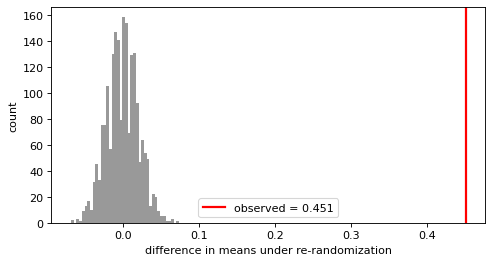

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(perm_stats, bins=40, color="grey", alpha=0.8)
ax.axvline(observed, color="red", lw=2, label=f"observed = {observed:.3f}")
ax.set_xlabel("difference in means under re-randomization")
ax.set_ylabel("count")
ax.legend()
plt.show()

如果激励没有任何作用，单凭随机分配的偶然性，均值差最多也就是正负 7 个百分点。实际观测到的 45 个百分点远在这个分布之外。

`sp.fisher_exact` 把这个过程打包，并通过反演检验给出置信区间。相当于 Stata 的 `ritest`。

In [8]:
ri = sp.fisher_exact(df, y="got", treatment="any", n_perm=2000, seed=0)
print(ri.summary())

Fisher's Exact Randomization Test
  Test statistic (ate):  0.450552
  Two-sided p-value:           0.0000
  One-sided p-value (greater):  0.0000
  95% CI (test inversion):  [0.4142, 0.4874]
------------------------------------------------------------
  Permutations:  2,000
  N (total):     2,834
  N (treated):   2,211


p 值显示为 0，意思是 2,000 次置换里没有一次达到观测值。规范的写法是 p < 1/2000。

随机化推断有三个特点值得记住。

- 它**不需要大样本**，也不需要对结果的分布做假设。样本很小或者结果分布很偏时尤其有用。
- 置换必须**模仿实际的随机化方案**。实验如果是分层随机或按群随机，置换也要在层内或按群进行（`stratify=`、`cluster=`）。
- 它检验的是精确原假设，比「平均效应为 0」更强。拒绝它说明至少对一部分人有效应。

## 6. 协变量调整

实验里加入协变量不是为了消除偏差，均值差本来就无偏。目的是**提高精度**。协变量如果能解释结果变量的一部分变异，把这部分扣掉之后剩余的噪声更小，标准误也更小。

传统的做法是把协变量直接加进回归。这样做在小样本下可能有偏，处理效应异质时甚至可能比不调整更不精确。Lin (2013) 给出了修正。把协变量**中心化**，再加入它们与处理变量的**交互项**。这样得到的估计量渐近地不会比均值差更差。

`sp.lm_lin` 实现了这个估计量，对应 R 的 `estimatr::lm_lin`。

In [9]:
adj = df.dropna(subset=["age"])
lin = sp.lm_lin(adj, y="got", treat="any", covariates=["age", "male", "distvct"])
unadjusted = sp.regress("got ~ any", data=adj, robust="hc2")

pd.DataFrame({
    "estimate": [unadjusted.params["any"], lin.estimate],
    "se": [unadjusted.std_errors["any"], lin.se],
}, index=["difference in means", "Lin (2013) adjusted"]).round(4)

,estimate,se
difference in means,0.4496,0.0209
Lin (2013) adjusted,0.4473,0.0209


调整之后估计值从 0.450 变成 0.447，几乎没有变化。第 3 节看到的年龄不平衡没有影响结论。标准误也几乎没变，因为这几个协变量对「是否领取结果」的解释力很弱。

协变量有预测力的时候，精度的提升可以很可观。下面用一个模拟说明，其中结果变量有一半以上的变异能被一个基线变量解释。

In [10]:
rng = np.random.default_rng(4)
n = 400
baseline = rng.normal(size=n)                        # 基线变量，比如处理前的结果
treat = rng.permutation(np.repeat([0, 1], n // 2))   # 完全随机分配，各一半
outcome = 0.3 * treat + 1.2 * baseline + rng.normal(size=n)
sim = pd.DataFrame({"y": outcome, "d": treat, "x": baseline})

raw = sp.regress("y ~ d", data=sim, robust="hc2")
lin_sim = sp.lm_lin(sim, y="y", treat="d", covariates=["x"])

print("真实效应 = 0.3")
pd.DataFrame({
    "estimate": [raw.params["d"], lin_sim.estimate],
    "se": [raw.std_errors["d"], lin_sim.se],
}, index=["difference in means", "Lin (2013) adjusted"]).round(3)

真实效应 = 0.3


,estimate,se
difference in means,0.368,0.158
Lin (2013) adjusted,0.385,0.103


标准误缩小了三分之一以上，相当于把样本量扩大了一倍多，却没有多花一分钱。这就是为什么实验设计阶段要收集好的基线数据，尤其是结果变量在处理之前的取值。

协变量调整有一条纪律。**放哪些协变量要在看到结果之前定好**，最好写进预注册的分析计划。事后试来试去直到结果显著，就失去了实验的意义。并且只能放处理之前确定的变量。

## 7. 剂量反应

代金券的金额也是随机的。这让我们可以问一个更细的问题，钱多一点，效果是不是也大一点？

In [11]:
bins = [-0.01, 0.0, 0.5, 1.0, 2.0, 3.0]
labels = ["0", "0-0.5", "0.5-1", "1-2", "2-3"]
df["amount"] = pd.cut(df["tinc"], bins=bins, labels=labels)

dose = df.groupby("amount", observed=True)["got"].agg(["mean", "count", "sem"])
dose.round(3)

,mean,count,sem
amount,,,
0,0.339,623,0.019
0-0.5,0.673,560,0.020
0.5-1,0.772,580,0.017
1-2,0.863,699,0.013
2-3,0.852,372,0.018


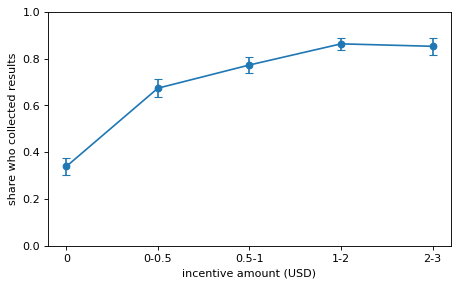

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.errorbar(range(len(dose)), dose["mean"], yerr=1.96 * dose["sem"], fmt="o-", capsize=4)
ax.set_xticks(range(len(dose)))
ax.set_xticklabels(dose.index)
ax.set_xlabel("incentive amount (USD)")
ax.set_ylabel("share who collected results")
ax.set_ylim(0, 1)
plt.show()

最大的跳跃发生在 0 和「一点点」之间。不到 0.5 美元的激励就把领取率从 34% 提高到 67%。金额继续增加，领取率还在上升，但幅度小得多，1 美元以上基本持平。

用回归把这两部分分开。`any` 的系数是「有没有激励」的效应，`tinc` 的系数是在有激励的前提下每多 1 美元的额外效应。

In [13]:
dose_reg = sp.regress("got ~ any + tinc", data=df, robust="hc2")
print(f"有激励本身的效应   : {dose_reg.params['any']:.3f}  (se {dose_reg.std_errors['any']:.3f})")
print(f"每多 1 美元的效应  : {dose_reg.params['tinc']:.3f}  (se {dose_reg.std_errors['tinc']:.3f})")

有激励本身的效应   : 0.343  (se 0.026)
每多 1 美元的效应  : 0.084  (se 0.011)


哪怕金额很小，只要有激励，领取率就大幅上升。这提示人们不去领结果的主要障碍可能不是路费这类经济成本，一个小小的推动就足以改变行为。这类发现只有在处理强度也被随机化的实验里才能得到。

## 8. 异质性与多重检验

激励对男性和女性的效果一样吗？对住得远的人呢？对年长的人呢？这类问题很自然，但分组分析是实验研究里最容易出问题的地方。

每多看一个分组，就多一次偶然得到「显著」结果的机会。看 20 个分组，即使效应完全同质，平均也会有 1 个在 5% 水平上显著。

正确的做法有两步。检验**交互项**而不是分别看两组各自是否显著，然后对多个检验做**多重比较校正**。

In [14]:
sub = df.dropna(subset=["age"]).copy()
sub["far"] = (sub["distvct"] > sub["distvct"].median()).astype(int)   # 住得比中位数远
sub["older"] = (sub["age"] > sub["age"].median()).astype(int)         # 年龄高于中位数

rows = []
for moderator in ("male", "far", "older"):
    fit = sp.regress(f"got ~ any * {moderator}", data=sub, robust="hc2")
    term = f"any:{moderator}"
    rows.append({
        "moderator": moderator,
        "effect when 0": fit.params["any"],
        "difference when 1": fit.params[term],
        "se": fit.std_errors[term],
        "p": fit.pvalues[term],
    })
het = pd.DataFrame(rows)

het["p (Holm)"] = sp.mht.adjust_pvalues(het["p"].to_numpy(), method="holm")
het.round(3)

,moderator,effect when 0,difference when 1,se,p,p (Holm)
0,male,0.447,0.005,0.042,0.908,1.00
1,far,0.450,0.000,0.042,0.996,1.00
2,older,0.474,-0.056,0.042,0.180,0.54


`difference when 1` 是交互项的系数，也就是该特征取 1 的人群与取 0 的人群之间效应的差别。最后一列是 Holm 校正后的 p 值，它控制「至少错误地拒绝一个原假设」的概率。

三个交互项在校正之后都不显著。激励对各个子群的效果大体相同，都在 45 个百分点上下。

关于异质性分析还有两条纪律。

- **事先指定**要看哪些分组，并在报告里列出**全部**看过的分组，不只是显著的那几个。
- 把事先指定的分析和探索性的分析分开汇报。探索性的发现是下一项研究的假设，不是这项研究的结论。

想要系统地估计异质性效应，可以看 `tutorial_hte_causal_forest.ipynb`。

## 9. 功效分析

功效分析在实验**之前**做。它回答的问题是，样本量要多大，才有足够的把握发现一个给定大小的效应。

**功效**是真实效应存在时检验能把它检测出来的概率，惯例取 80%。功效不足的实验很可能白做，而且一旦得到显著结果，效应的估计值往往被严重夸大。

对于比例类的结果，`sp.power_two_proportions` 既可以在给定样本量时算功效，也可以在给定功效时反解样本量。

In [15]:
# 这项实验实际的功效。34% 对 79%，共 2,834 人
actual = sp.power_two_proportions(n=2834, p1=0.34, p2=0.79, ratio=n1 / n0)
print(f"检测 45 个百分点的效应，实际功效 = {actual.power:.3f}")

# 如果预期的效应小得多，需要多大的样本
rows = []
for lift in (0.20, 0.10, 0.05, 0.03):
    need = sp.power_two_proportions(n=None, p1=0.34, p2=0.34 + lift, power_target=0.80)
    rows.append({"effect (percentage points)": int(round(lift * 100)), "total n for 80% power": int(need.n)})
pd.DataFrame(rows)

检测 45 个百分点的效应，实际功效 = 1.000


,effect (percentage points),total n for 80% power
0,20,186
1,10,740
2,5,2903
3,3,7980


这项实验的效应极大，功效实际上是 100%。但设计实验时并不知道效应有多大。

表里的规律值得记住。效应减半，需要的样本量大约是原来的四倍。想检测 5 个百分点的效应需要将近 3,000 人，3 个百分点则需要 8,000 人左右。

做功效分析时最难的是确定「预期效应」。常见的错误是拿以往文献里的显著结果当预期，这些数字本身往往被高估了。更稳妥的问法是，多小的效应仍然有政策意义？就按那个效应来设计样本量。

## 10. 小结

1. **在分析之前写好计划**。主要结果、估计量、协变量、要看的分组，最好预注册。
2. **检查平衡**（`sp.balance_table`）。它检查的是随机化的执行。看差别的大小，不要过度解读个别显著的 p 值。
3. **主估计用均值差**（`sp.regress("y ~ d", robust="hc2")`）。标准误按随机化的层级聚类。
4. **用随机化推断复核**（`sp.fisher_exact`），置换方案要与实际的随机化一致。
5. **协变量调整为的是精度**（`sp.lm_lin`）。只放处理前的变量，事先定好。
6. **处理强度若被随机化，报告剂量反应**。
7. **分组分析检验交互项，并做多重比较校正**（`sp.mht.adjust_pvalues`）。
8. **实验之前做功效分析**（`sp.power_two_proportions`、`sp.power_ttest`、`sp.power_cluster_rct`）。

### 本教程用到的方法的文献

下面的 BibTeX 条目直接取自 StatsPAI 核验过的 `paper.bib`。

In [16]:
keys = [
    "thornton2008demand",
    "fisher1935design",
    "lin2013agnostic",
    "holm1979simple",
    "imbens2015causal",
]
print(sp.bibtex(keys))

@article{thornton2008demand,
  title={The Demand for, and Impact of, Learning HIV Status},
  author={Thornton, Rebecca L.},
  journal={American Economic Review},
  volume={98},
  number={5},
  pages={1829--1863},
  year={2008},
  publisher={American Economic Association},
  doi={10.1257/aer.98.5.1829}
}

@book{fisher1935design,
  title={The Design of Experiments},
  author={Fisher, Ronald A.},
  publisher={Oliver and Boyd, Edinburgh},
  year={1935},
  annote={No DOI: 10.2307/2343406 is a Journal of the Royal Statistical Society review of a later edition, not the book. Verified 2026-08-24 via Crossref and doi.org.}
}

@article{lin2013agnostic,
  title={Agnostic notes on regression adjustments to experimental data: Reexamining Freedman's critique},
  author={Lin, Winston},
  journal={The Annals of Applied Statistics},
  volume={7},
  number={1},
  pages={295--318},
  year={2013},
  doi={10.1214/12-AOAS583}
}

@article{holm1979simple,
  title={A Simple Sequentially Rejective Multiple Test